<div style="text-align: center;">

  <!-- Logotipo -->
  <img src="img/LogoUesc.png" alt="UESC" style="width: 60px; display: block; margin: 0 auto 5px auto;">

  <!-- Cabeçalho -->
  <div style="font-size: 20px;"><strong>UNIVERSIDADE ESTADUAL DE SANTA CRUZ - UESC</strong></div>
  <div style="font-size: 18px;">DEPARTAMENTO DE ENGENHARIAS E COMPUTAÇÃO</div>
  <div style="font-size: 18px;">ENGENHARIA QUÍMICA</div>

  <hr style="margin: 20px 0; border: 1px solid #0074B7;">

  <!-- Título do Trabalho -->
  <div style="font-size: 22px; font-weight: bold; margin-bottom: 10px;">Controle de Processos Aplicado na Engenharia Química</div>
  <div style="font-size: 20px; font-weight: bold; margin-bottom: 10px;">Aplicação de PID no Controle de Forno Industrial</div>

  <!-- Autor e orientador -->
  <div style="font-size: 18px;">Prof. Dr. E.R.Edwards</div>

<hr style="margin: 20px 0; border: 1px solid #0074B7;">
  <!-- Data -->
<!-- <div style="font-size: 16px; margin-top: 15px;">Ilhéus - BA, Abril de 2025</div> -->
</div>

<div style="background-color: #e6f2ff; border-left: 6px solid #0074B7; padding: 10px; font-size: 16px;">
  <strong>Controle de Temperatura de um Forno Industrial com PID usando programação em Python.</strong> 
</div>

Neste notebook vamos entender como funciona o **controle de temperatura de um forno industrial** e como podemos representar esse sistema usando um controlador PID em Python.

A figura abaixo mostra três elementos fundamentais do processo:

1. **O forno físico**  
   No interior do forno existem resistências elétricas nas laterais. Quando a corrente elétrica aumenta, a potência dissipada nas resistências também aumenta, produzindo mais calor. Assim, o forno aquece por **efeito Joule**.

2. **O sensor de temperatura (termopar)**  
   O termopar mede a temperatura interna do forno e envia um sinal analógico proporcional à temperatura. Esse sinal é convertido para digital por um módulo **A/D**, permitindo que o controlador receba a temperatura medida.

3. **O diagrama de blocos do sistema de controle**  
   O controlador recebe:
   - a temperatura desejada (*setpoint*), $(T_{sp})$,
   - a temperatura medida (*process variable*), $(T_{pv})$,
   - calcula o erro:  $e(t) = T_{sp} - T_{pv}$

   - e ajusta a potência enviada às resistências para reduzir esse erro.

O objetivo do controlador é simples: **fazer a temperatura medida igual à temperatura desejada**, mantendo o forno estável e sem oscilações excessivas.


<img src="img/corrente_forno_eletrico.png" alt="UESC" style="width: 700px; display: block; margin: 0 auto 5px auto;">
<p style="text-align: center;"><strong>Figura esquemática de um forno elétrico, sua vista interna, a visualização de corrente com resistência elétrica e o diagrama de blocos representativo deste sistema.</strong></p>

Ao abrir o bloco PID no diagrama, vemos que ele é formado pela soma de três ações de controle: **Proporcional (P)**, **Integral (I)** e **Derivativa (D)**.  Cada uma delas contribui de forma diferente para reduzir o erro e estabilizar a temperatura do forno.
 

<img src="img/soma_controladores_pid.png" alt="UESC" style="width: 650px; display: block; margin: 0 auto 5px auto;">
<p style="text-align: center;"><strong>Diagrama esquemático mostrando os controladores PID no diagrama de blocos.</strong></p>

Antes de implementarmos o controlador, vamos relembrar o papel de cada ação do PID:

- **Proporcional (P)**: reage ao erro atual. Quanto maior o erro, maior a correção aplicada.
- **Integral (I)**: acumula o erro ao longo do tempo. É responsável por eliminar o erro em regime permanente.
- **Derivativo (D)**: reage à velocidade com que o erro está mudando. Ajuda a evitar oscilações e melhora a estabilidade.

Essas três ações juntas formam o controlador PID, que ajusta a potência do forno para manter a temperatura no valor desejado.


Agora vamos aplicar esses conceitos para controlar a temperatura de um forno industrial usando Python.

### **Dados do problema**

- Temperatura desejada (*setpoint*): $(300^\circ\text{C})$
- Temperatura inicial do forno: $(200^\circ\text{C})$
- Intervalo de amostragem: **1 segundo**
- Constantes do controlador PID:
  - $K_p = 0.1$
  - $K_i = 0.01$
  - $K_d = 0.001$

Com esses valores, vamos implementar o controlador PID passo a passo e observar como a temperatura do forno evolui ao longo do tempo.


Agora vamos relacionar o diagrama de blocos do sistema de controle com as linhas de código do controlador PID. 
 
A ideia é mostrar que cada parte do diagrama corresponde diretamente a uma etapa do código.

No diagrama, temos:

- A temperatura desejada (*setpoint*), $(T_{sp})$
- A temperatura medida (*process variable*), $(T_{pv})$
- O cálculo do erro: $e(t) = T_{sp} - T_{pv}$

- O bloco PID, formado pelas ações:
  - Proporcional (P)
  - Integral (I)
  - Derivativa (D)
- A saída do controlador, $(u(t))$, que ajusta a potência das resistências
- A planta (o forno), cuja temperatura aumenta conforme a potência aplicada
- O sensor (termopar), que mede a temperatura e fecha o ciclo de realimentação

Cada uma dessas etapas aparece claramente no código Python.


A função `controlador_pid` implementa exatamente o diagrama de blocos:

### 1. Inicialização das variáveis
- $T_{pv}$: temperatura atual do forno  
- $e(t)$: erro  
- Integral acumulada  
- Erro anterior (para o termo derivativo)

### 2. Cálculo do erro

$e(t) = T_{sp} - T_{pv}$

### 3. Ações do controlador PID
- **Proporcional**: $P(t) = K_p \cdot e(t)$

- **Integral**: $I(t) = I(t-1) + K_i \cdot e(t)$

- **Derivativa**: $D(t) = K_d \cdot (e(t) - e(t-1))$

### 4. Saída do controlador

$u(t) = P(t) + I(t) + D(t)$

### 5. Atualização da planta (forno)
A saída do controlador aumenta a temperatura do forno:

$T_{pv}(t+1) = T_{pv}(t) + u(t)$

### 6. Armazenamento dos resultados
Cada nova temperatura é guardada para gerar o gráfico final.


A seguir está o código completo do controlador PID, com cada parte correspondendo ao diagrama de blocos apresentado anteriormente.

In [11]:
# Importação de bibliotecas
import matplotlib.pyplot as plt

def controlador_pid(setpoint, temperatura_inicial, Kp, Ki, Kd, tempo_total):
    # Inicialização das variáveis do controlador
    erro_anterior = 0
    integral = 0
    temperatura_atual = temperatura_inicial
    resultado = []

    for t in range(tempo_total):
        # Cálculo do erro: e(t) = Tsp - Tpv
        erro = setpoint - temperatura_atual

        # Ação Proporcional
        proporcional = erro * Kp

        # Ação Integral
        integral += erro * Ki

        # Ação Derivativa
        derivativo = (erro - erro_anterior) * Kd

        # Saída do controlador PID
        saida = proporcional + integral + derivativo
        
        # Atualização da planta (forno)
        temperatura_atual += saida
        
        # Armazenamento dos resultados
        resultado.append(temperatura_atual)
        
        # Atualização do erro anterior
        erro_anterior = erro

    return resultado

# Parâmetros do controlador
setpoint = 300
temperatura_inicial = 200  # Para fins didáticos, vamos iniciar a simulação em 200°C. 
                           # O controlador PID funciona desde a temperatura ambiente, 
                           # mas começamos em 200°C para visualizar melhor a ação do 
						   # controle próximo ao setpoint.

Kp = 0.1
Ki = 0.01
Kd = 0.001
tempo_total = 100  # Tempo total de simulação (em segundos)

# Execução do controlador PID
resultados = controlador_pid(setpoint, temperatura_inicial, Kp, Ki, Kd, tempo_total)


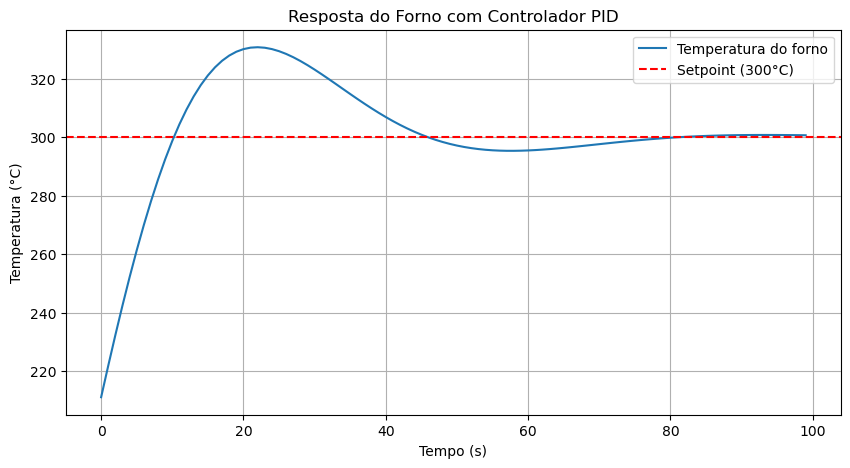

In [12]:
#-----------------------------
# Gráfico da temperatura
#-----------------------------
tempo = range(tempo_total)

plt.figure(figsize=(10, 5))
plt.plot(tempo, resultados, label="Temperatura do forno")
plt.axhline(setpoint, color="red", linestyle="--", label="Setpoint (300°C)")
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Resposta do Forno com Controlador PID")
plt.legend()
plt.grid(True)
plt.show()

Com o controlador implementado, agora podemos visualizar como a temperatura do forno evolui ao longo do tempo e observar o efeito das ações P, I e D na resposta do sistema.


<div style="text-align: center; font-size: 12px; color: gray; margin-top: 40px;">
  Este notebook foi desenvolvido no âmbito do Grupo de Pesquisas em Modelagem Computacional da UESC.<br>
  Todos os direitos reservados © 2025
</div>